CUSTOMER CHURN ANALYSIS

A telecom company loses its customers. Each lost customer creates a  loss in recurring revenue. This project analyses the features are more likely affecting customer churn, so the business  can intervene with offers, discounts and other better services

In [2]:
#importing necessary libraries
import numpy as np
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data loading and preview

In [3]:
df=pd.read_csv(r'C:/Customer_Churn_Predicton_Project/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
#to find blank values
(df==' ').sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
(df['TotalCharges']==' ').sum()

np.int64(11)

In [13]:
df['TotalCharges']=df['TotalCharges'].replace(' ',np.nan)
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])

In [14]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

In [15]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.columns=df.columns.str.lower()
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

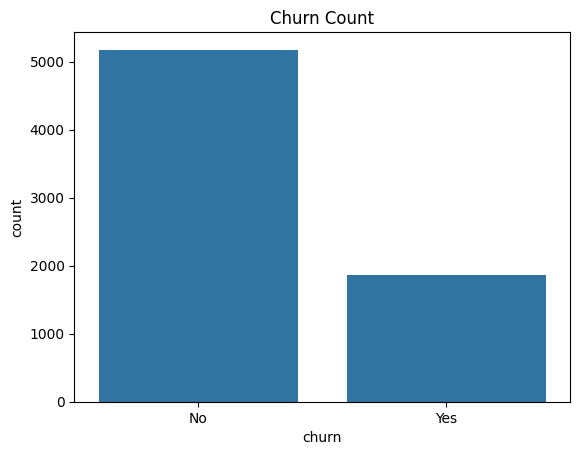

In [24]:
sns.countplot(data=df,x='churn')
plt.title('Churn Count')
plt.show()

In [26]:
(df['churn'].value_counts(normalize=True)*100).round(2)

churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

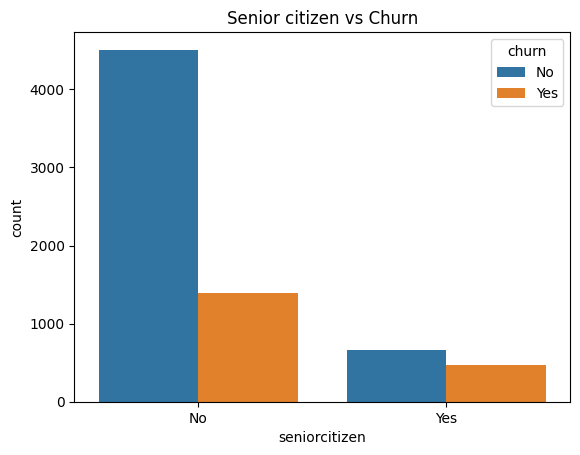

In [30]:
df['seniorcitizen']=df['seniorcitizen'].map({0:'No',1:'Yes'})
sns.countplot(data=df,x='seniorcitizen',hue='churn')
plt.title('Senior citizen vs Churn')
plt.xticks(rotation=0)
plt.show()


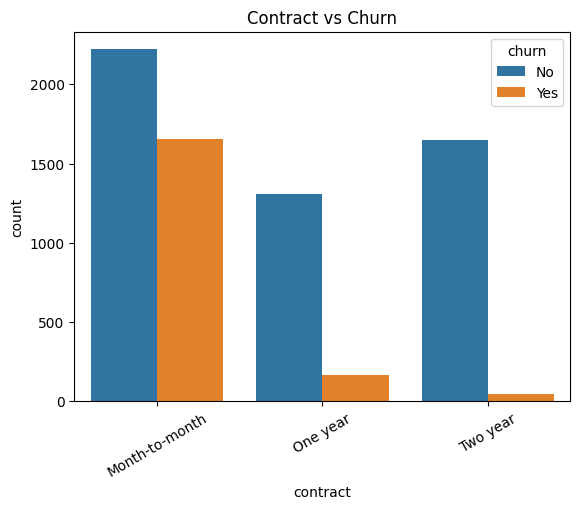

In [33]:
sns.countplot(data=df,x='contract',hue='churn')
plt.title('Contract vs Churn')
plt.xticks(rotation=30)
plt.show()

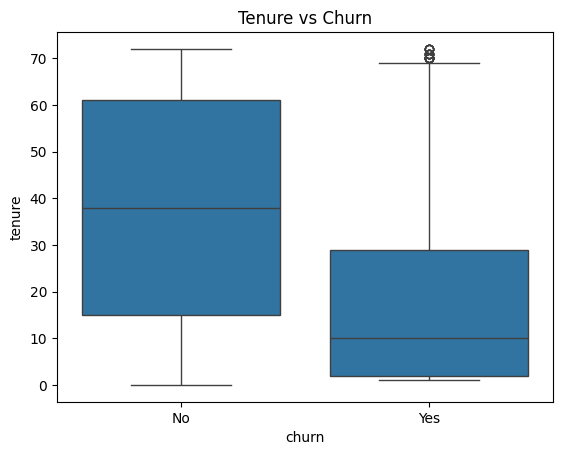

In [34]:
sns.boxplot(data=df,x='churn',y='tenure')
plt.title('Tenure vs Churn')
plt.show()

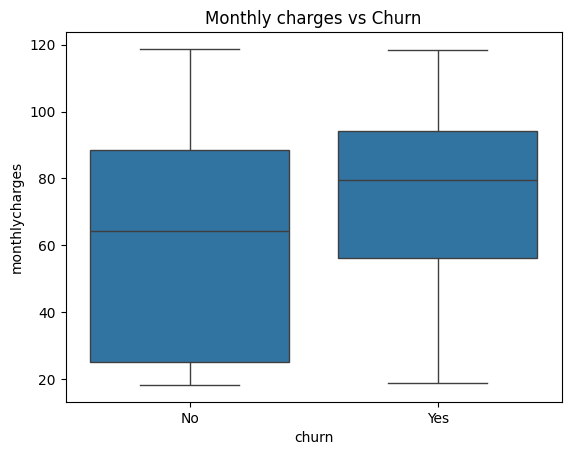

In [35]:
sns.boxplot(x='churn',y='monthlycharges',data=df)
plt.title('Monthly charges vs Churn')
plt.show()

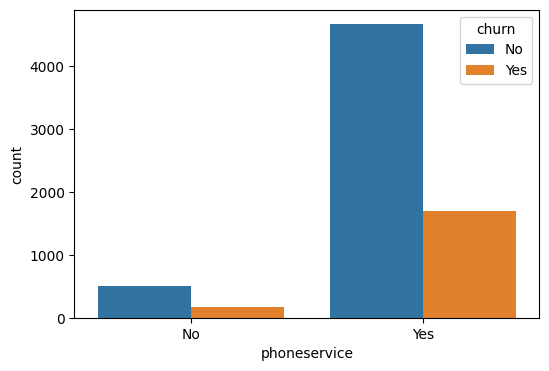

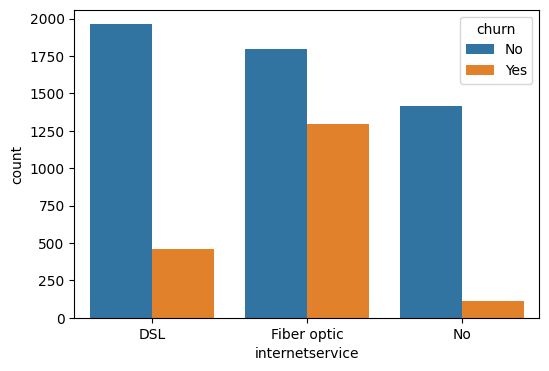

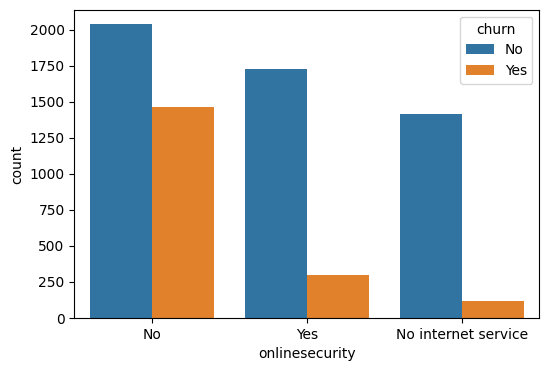

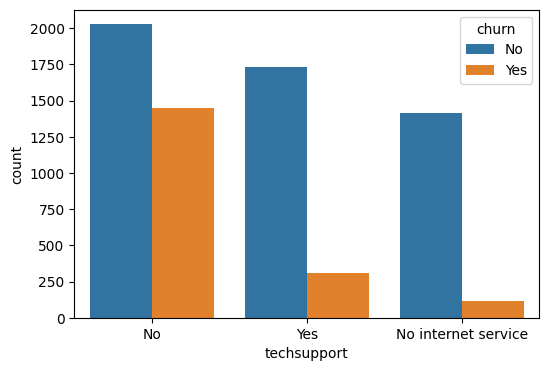

In [37]:
cols=['phoneservice','internetservice',
      'onlinesecurity','techsupport']
for col in cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col,hue='churn',data=df)
    plt.show()

<Axes: >

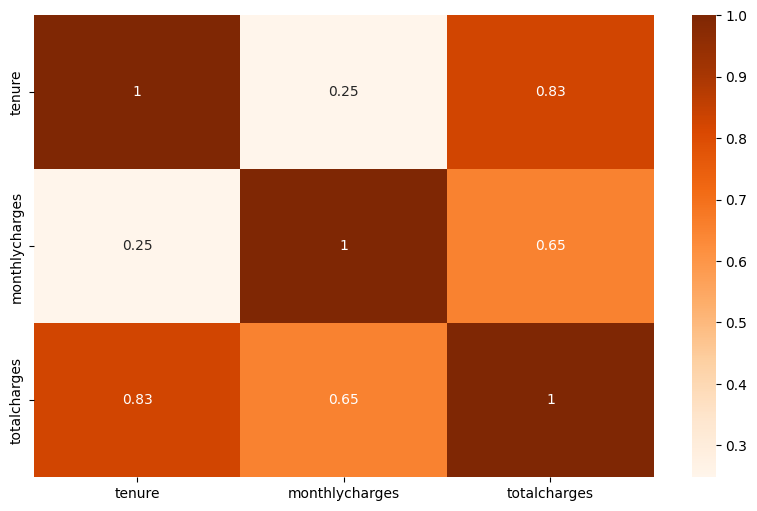

In [43]:
num_df=df.select_dtypes(include=np.number)
corr=num_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap='Oranges')

In [44]:
df.to_csv('cleaned_churn.csv',index=False)

In [45]:
pip install pyodbc

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import sqlalchemy
from sqlalchemy import create_engine

# Load dataset
df = pd.read_csv("cleaned_churn.csv")

# SQL Server connection
engine = create_engine(
    "mssql+pyodbc://DESKTOP-B0EMSLN\SQLEXPRESS/Customer_churn"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

# Create table automatically and insert data
df.to_sql(
    name='customer_churn',
    con=engine,
    if_exists='replace',  # drops and recreates table
    index=False
)

print("Data imported successfully!")

<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Jumbo\AppData\Local\Temp\ipykernel_23396\1704002709.py:9: SyntaxWarning: invalid escape sequence '\S'
  "mssql+pyodbc://DESKTOP-B0EMSLN\SQLEXPRESS/Customer_churn"


Data imported successfully!
